
# Close Is Not the Same as Reachable

## Comparing Euclidean and Walking-Network Distance to Small Urban Refuges

### Research statement

This project asks:

> How does Manhattan's pedestrian street network change the apparent
> accessibility of small refuge spaces from Avery Hall?

A destination can appear nearby when measured as a straight line, while an
actual walking route must follow streets, paths, intersections, entrances, and
other constraints. I compare:

1. **Euclidean distance** — the direct straight-line distance between Avery Hall
   and each refuge.
2. **Network distance** — the shortest walking route through the OpenStreetMap
   pedestrian network.

The study uses locations from my earlier dataset, **A Personal Atlas of Small
Refuges**. Avery Hall is the origin. Selected libraries, parks, museums, and
public interior spaces are the destination nodes.

### Course-tutorial workflow

This notebook follows the same OSMnx sequence used in the course tutorial:

```text
ox.graph_from_point()
→ ox.graph_to_gdfs()
→ ox.distance.nearest_nodes()
→ ox.shortest_path(weight="length")
→ ox.plot_graph_route()
→ ox.routing.route_to_gdf()
→ DataFrame.apply()
→ pd.concat()
```


## 1. Import libraries

In [22]:

# Run this cell once if packages are missing:
# %pip install osmnx geopandas matplotlib pandas numpy

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import osmnx as ox

from pathlib import Path
from shapely.geometry import LineString

plt.rcParams["figure.figsize"] = (10, 9)
plt.rcParams["figure.dpi"] = 130

DATA_PATH = Path("data/small_refuges.geojson")



## 2. Load and select the measured nodes

The source dataset contains refuge spaces across New York City. To keep the
walking network focused and computationally manageable, this analysis uses
Avery Hall as the origin and nine Manhattan refuge spaces as destinations.


In [23]:

refuges = gpd.read_file(DATA_PATH)

origin = refuges[
    refuges["place_name"]
    == "Avery Architectural & Fine Arts Library"
].copy()

origin["place_name"] = "Avery Hall"
origin["node_role"] = "origin"

selected_names = [
    "Butler Library",
    "Morningside Heights Library",
    "Sakura Park",
    "Riverside Park Overlook at 116th Street",
    "West Harlem Piers Park",
    "Morningside Park",
    "The Metropolitan Museum of Art",
    "Cooper Hewitt Garden",
    "Museum of the City of New York",
]

destinations = refuges[
    refuges["place_name"].isin(selected_names)
].copy()

destinations["node_role"] = "destination"

print(f"Origin: {origin.iloc[0]['place_name']}")
print(f"Number of destination nodes: {len(destinations)}")

destinations[
    [
        "place_name",
        "place_type",
        "neighborhood",
        "quiet_score",
        "welcome_score",
    ]
].reset_index(drop=True)


Origin: Avery Hall
Number of destination nodes: 9


,place_name,place_type,neighborhood,quiet_score,welcome_score
0,Butler Library,university_library,Morningside Heights,4,4
1,Morningside Heights Library,public_library,Morningside Heights,4,5
2,Sakura Park,park,Morningside Heights,4,4
3,Riverside Park Overlook at 116th Street,park,Morningside Heights,4,4
4,West Harlem Piers Park,waterfront_park,West Harlem,3,4
5,Morningside Park,park,Harlem,3,3
6,The Metropolitan Museum of Art,museum,Upper East Side,3,4
7,Cooper Hewitt Garden,museum_garden,Carnegie Hill,4,5
8,Museum of the City of New York,museum,East Harlem,4,4



### Nodes being measured

The place points are not yet network nodes. Later, each geographic location is
associated with the nearest OpenStreetMap walking-network node using
`ox.distance.nearest_nodes()`.


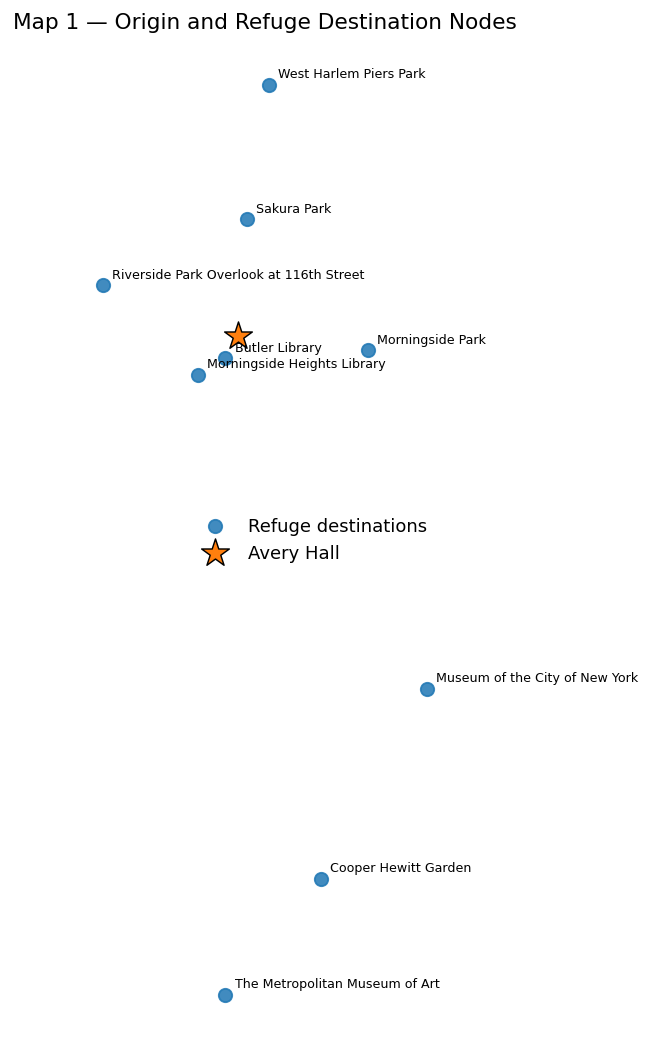

In [24]:

fig, ax = plt.subplots(figsize=(8, 10))

destinations.plot(
    ax=ax,
    markersize=55,
    alpha=0.85,
    label="Refuge destinations",
)

origin.plot(
    ax=ax,
    marker="*",
    markersize=260,
    edgecolor="black",
    linewidth=0.8,
    label="Avery Hall",
)

for _, row in destinations.iterrows():
    ax.annotate(
        row["place_name"],
        (row.geometry.x, row.geometry.y),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_title("Map 1 — Origin and Refuge Destination Nodes")
ax.legend(frameon=False)
ax.set_axis_off()
plt.show()



## 3. Create the real pedestrian network

Following the teacher's tutorial, `ox.graph_from_point()` downloads a walking
network from OpenStreetMap around the selected origin.

- Center: Avery Hall
- Radius: 5,500 meters
- Network type: `walk`

The result is a NetworkX `MultiDiGraph` whose nodes are intersections or points
along paths and whose edges are walkable segments.


In [25]:
import os

for variable in [
    "HTTP_PROXY",
    "HTTPS_PROXY",
    "ALL_PROXY",
    "http_proxy",
    "https_proxy",
    "all_proxy",
]:
    os.environ.pop(variable, None)

print({
    key: value
    for key, value in os.environ.items()
    if "proxy" in key.lower()
})

{}


In [26]:

origin_lon = origin.geometry.iloc[0].x
origin_lat = origin.geometry.iloc[0].y

point_network = ox.graph_from_point(
    (origin_lat, origin_lon),
    dist=5500,
    network_type="walk",
)

point_network


Convert the graph's nodes and edges into GeoDataFrames, as in the tutorial.

In [27]:

net_nodes, net_edges = ox.graph_to_gdfs(point_network)

print(f"Network nodes: {len(net_nodes):,}")
print(f"Network edges: {len(net_edges):,}")

net_edges[
    [
        "length",
        "highway",
        "geometry",
    ]
].head()


Network nodes: 33,066
Network edges: 105,746


length    highway  \
u        v          key                          
30807314 2057103273 0    159.255042  bridleway   
         6579409036 0     58.144181  bridleway   
         4303265016 0     10.509449    footway   
         1203806304 0     17.645411    footway   
30978747 42442164   0     18.986534       path   

                                                                  geometry  
u        v          key                                                     
30807314 2057103273 0    LINESTRING (-73.96358 40.79072, -73.9636 40.79...  
         6579409036 0    LINESTRING (-73.96358 40.79072, -73.96354 40.7...  
         4303265016 0    LINESTRING (-73.96358 40.79072, -73.96353 40.7...  
         1203806304 0    LINESTRING (-73.96358 40.79072, -73.96368 40.7...  
30978747 42442164   0    LINESTRING (-73.97342 40.77427, -73.97365 40.7...

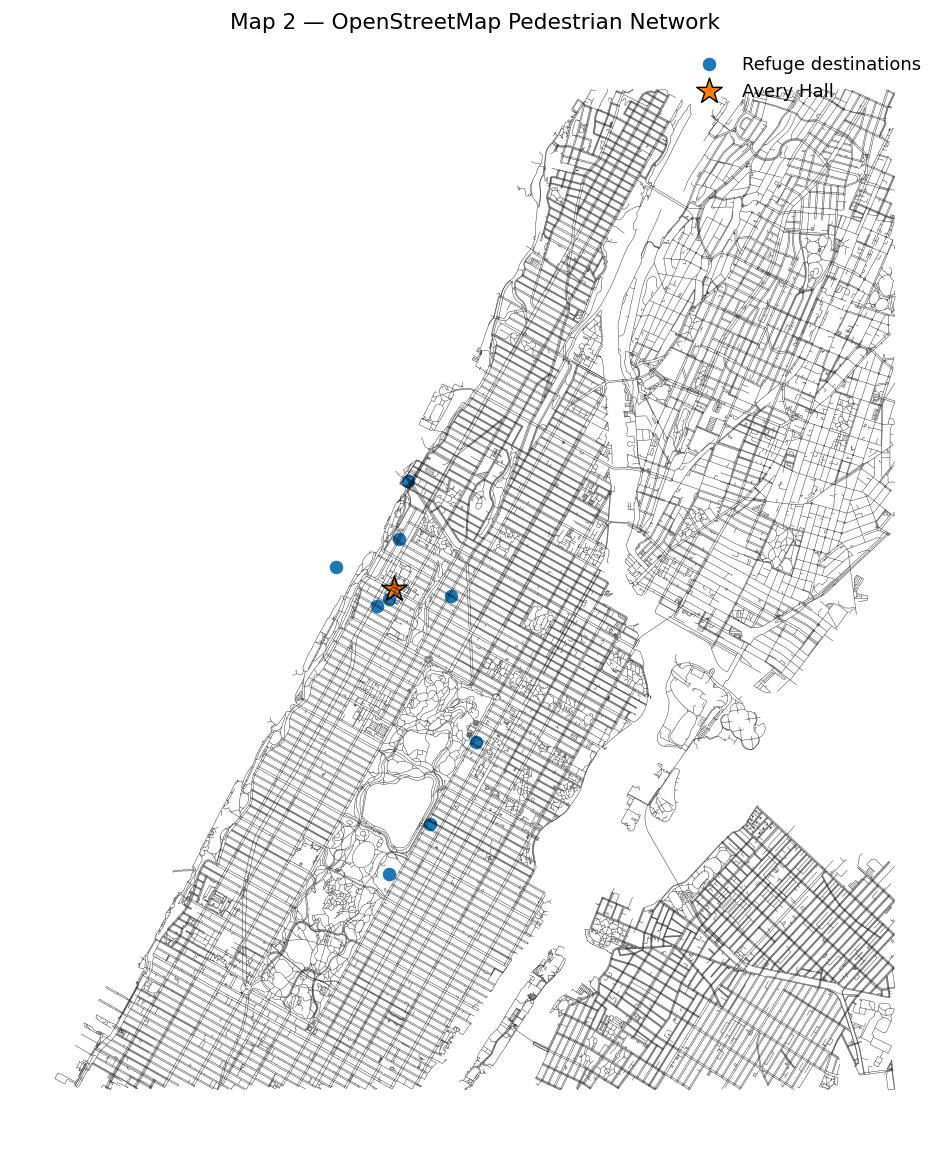

In [28]:

fig, ax = plt.subplots(figsize=(10, 11))

net_edges.plot(
    ax=ax,
    color="black",
    linewidth=0.25,
    alpha=0.45,
)

destinations.plot(
    ax=ax,
    markersize=42,
    label="Refuge destinations",
)

origin.plot(
    ax=ax,
    marker="*",
    markersize=220,
    edgecolor="black",
    linewidth=0.8,
    label="Avery Hall",
)

ax.set_title("Map 2 — OpenStreetMap Pedestrian Network")
ax.legend(frameon=False)
ax.set_axis_off()
plt.show()



## 4. Associate the places with their nearest network nodes

The teacher's tutorial first translates geographic points into positions on the
network. `nearest_nodes()` finds the closest graph node for Avery Hall and for
each refuge destination.


In [29]:

orig = ox.distance.nearest_nodes(
    point_network,
    origin_lon,
    origin_lat,
)

destinations["network_node"] = ox.distance.nearest_nodes(
    point_network,
    destinations.geometry.x,
    destinations.geometry.y,
)

print("Avery Hall network node:", orig)

destinations[
    [
        "place_name",
        "network_node",
    ]
]


Avery Hall network node: 2308955248


,place_name,network_node
1,Butler Library,3907629298
2,Morningside Heights Library,13684300884
3,Sakura Park,6244980561
4,Riverside Park Overlook at 116th Street,7934826779
5,West Harlem Piers Park,10049925998
6,Morningside Park,11840449880
12,The Metropolitan Museum of Art,8039596493
14,Cooper Hewitt Garden,5306313702
15,Museum of the City of New York,2761794331



## 5. Calculate Euclidean distance

The origin and destinations are projected into a local metric coordinate system
before calculating straight-line distance.

Euclidean distance treats movement as a direct line across an unobstructed
plane:

\[
d_E = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}
\]


In [30]:

metric_crs = destinations.estimate_utm_crs()

origin_metric = origin.to_crs(metric_crs)
destinations_metric = destinations.to_crs(metric_crs)

origin_metric_point = origin_metric.geometry.iloc[0]

destinations["euclidean_m"] = (
    destinations_metric.geometry.distance(origin_metric_point)
)

destinations["euclidean_km"] = (
    destinations["euclidean_m"] / 1000
)

destinations[
    [
        "place_name",
        "euclidean_km",
    ]
].sort_values("euclidean_km").round(2)


,place_name,euclidean_km
1,Butler Library,0.12
2,Morningside Heights Library,0.26
3,Sakura Park,0.55
6,Morningside Park,0.62
4,Riverside Park Overlook at 116th Street,0.68
5,West Harlem Piers Park,1.20
15,Museum of the City of New York,1.90
14,Cooper Hewitt Garden,2.60
12,The Metropolitan Museum of Art,3.12



## 6. Find one shortest route

Before calculating all destinations, reproduce the tutorial's single-route
example. The route is minimized using the `length` attribute of every edge.


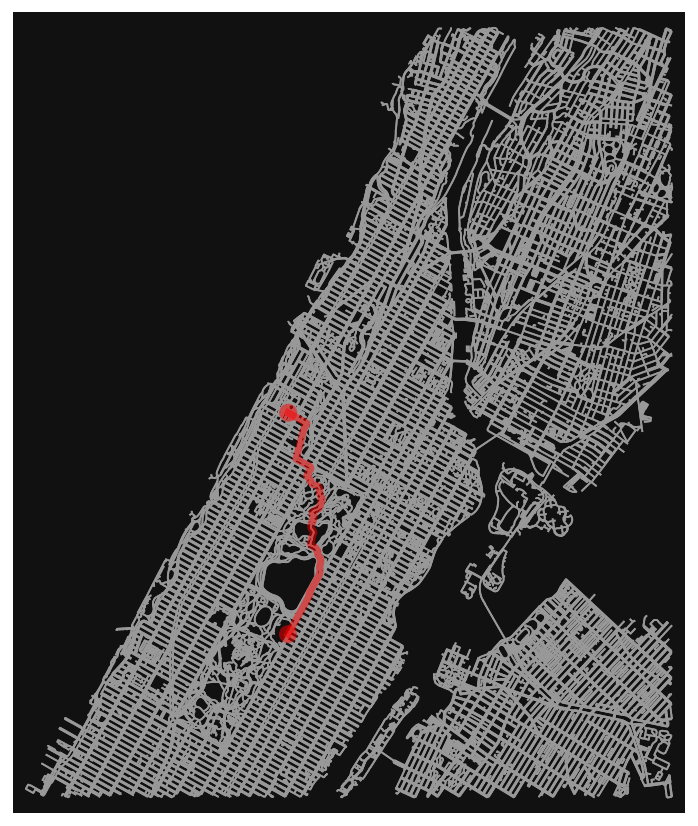

In [31]:

sample_destination = destinations[
    destinations["place_name"]
    == "The Metropolitan Museum of Art"
].iloc[0]

dest = ox.distance.nearest_nodes(
    point_network,
    sample_destination.geometry.x,
    sample_destination.geometry.y,
)

route = ox.shortest_path(
    point_network,
    orig,
    dest,
    weight="length",
)

fig, ax = ox.plot_graph_route(
    point_network,
    route,
    node_size=0,
    route_linewidth=4,
)



As in the tutorial, `route` is an ordered list of network-node IDs. Convert it
to an edge GeoDataFrame and sum its `length` values.


In [32]:

sample_route_edges = ox.routing.route_to_gdf(
    point_network,
    route,
)

sample_distance_km = (
    sample_route_edges["length"].sum() / 1000
)

print(
    "Walking-network distance from Avery Hall "
    "to The Metropolitan Museum of Art:"
)
print(round(sample_distance_km, 2), "km")


Walking-network distance from Avery Hall to The Metropolitan Museum of Art:
3.93 km



## 7. Calculate the shortest route to every refuge

This function closely follows the `distance_from_point()` function in the
teacher's tutorial. For each row, it:

1. finds the nearest destination node;
2. calculates the shortest route;
3. converts the route to a GeoDataFrame;
4. sums edge lengths;
5. merges the route geometries.


In [33]:

# Calculate the connector distance from Avery Hall
# to its nearest street-network node.
origin_node_data = point_network.nodes[orig]

origin_connector_m = ox.distance.great_circle(
    origin_lat,
    origin_lon,
    origin_node_data["y"],
    origin_node_data["x"],
)


def distance_from_avery(row, origin_node):
    """
    Calculate the complete walking distance from Avery Hall
    to one refuge destination.

    The distance includes:
    1. Avery Hall to its nearest network node;
    2. the shortest path through the walking network;
    3. the destination's nearest network node to the destination.
    """

    dest = ox.distance.nearest_nodes(
        point_network,
        row.geometry.x,
        row.geometry.y,
    )

    route = ox.shortest_path(
        point_network,
        origin_node,
        dest,
        weight="length",
    )

    route_gdf = ox.routing.route_to_gdf(
        point_network,
        route,
    )

    network_edge_distance_m = route_gdf["length"].sum()

    destination_node_data = point_network.nodes[dest]

    destination_connector_m = ox.distance.great_circle(
        row.geometry.y,
        row.geometry.x,
        destination_node_data["y"],
        destination_node_data["x"],
    )

    complete_network_distance_m = (
        origin_connector_m
        + network_edge_distance_m
        + destination_connector_m
    )

    route_geom = route_gdf.geometry.union_all()

    return {
        "network_m": complete_network_distance_m,
        "route_geom": route_geom,
        "origin_connector_m": origin_connector_m,
        "destination_connector_m": destination_connector_m,
    }
    dest = ox.distance.nearest_nodes(
        point_network,
        row.geometry.x,
        row.geometry.y,
    )

    route = ox.shortest_path(
        point_network,
        origin_node,
        dest,
        weight="length",
    )

    route_gdf = ox.routing.route_to_gdf(
        point_network,
        route,
    )

    edge_lengths = route_gdf["length"]
    route_geom = route_gdf.geometry.union_all()

    return {
        "network_m": edge_lengths.sum(),
        "route_geom": route_geom,
    }


In [34]:

destinations["distance_from_avery"] = destinations.apply(
    distance_from_avery,
    origin_node=orig,
    axis=1,
)

destinations["distance_from_avery"].head()


1    {'network_m': 170.77606977355265, 'route_geom'...
2    {'network_m': 427.02793913079057, 'route_geom'...
3    {'network_m': 780.2253865031608, 'route_geom':...
4    {'network_m': 797.4927695278683, 'route_geom':...
5    {'network_m': 1453.0430829972674, 'route_geom'...
Name: distance_from_avery, dtype: object


Following the tutorial, each returned dictionary is expanded into separate
columns with `pd.Series`, and concatenated back into the destination
GeoDataFrame.


In [35]:

destinations = pd.concat(
    [
        destinations.drop(
            columns=["distance_from_avery"]
        ),
        destinations[
            "distance_from_avery"
        ].apply(pd.Series),
    ],
    axis=1,
)

destinations["network_km"] = (
    destinations["network_m"] / 1000
)

destinations[
    [
        "place_name",
        "euclidean_km",
        "network_km",
    ]
].sort_values("network_km").round(2)


,place_name,euclidean_km,network_km
1,Butler Library,0.12,0.17
2,Morningside Heights Library,0.26,0.43
3,Sakura Park,0.55,0.78
4,Riverside Park Overlook at 116th Street,0.68,0.80
6,Morningside Park,0.62,0.93
5,West Harlem Piers Park,1.20,1.45
15,Museum of the City of New York,1.90,2.39
14,Cooper Hewitt Garden,2.60,3.33
12,The Metropolitan Museum of Art,3.12,4.03



## 8. Compare the two forms of distance

The additional distance imposed by the network is:

\[
d_{extra} = d_N - d_E
\]

The detour factor is:

\[
\text{detour factor} = \frac{d_N}{d_E}
\]

A value of 1 would mean that the walking route is identical to the straight
line. Values above 1 indicate that the network requires extra movement.


In [36]:

destinations["extra_distance_m"] = (
    destinations["network_m"]
    - destinations["euclidean_m"]
)

destinations["extra_distance_km"] = (
    destinations["extra_distance_m"] / 1000
)

destinations["detour_factor"] = (
    destinations["network_m"]
    / destinations["euclidean_m"]
)

destinations["euclidean_rank"] = (
    destinations["euclidean_m"]
    .rank(method="min")
    .astype(int)
)

destinations["network_rank"] = (
    destinations["network_m"]
    .rank(method="min")
    .astype(int)
)

destinations["rank_change"] = (
    destinations["network_rank"]
    - destinations["euclidean_rank"]
)

result_columns = [
    "place_name",
    "euclidean_km",
    "network_km",
    "extra_distance_km",
    "detour_factor",
    "euclidean_rank",
    "network_rank",
    "rank_change",
]

destinations[
    result_columns
].sort_values("network_km").round(2)


,place_name,euclidean_km,network_km,extra_distance_km,detour_factor,euclidean_rank,network_rank,rank_change
1,Butler Library,0.12,0.17,0.05,1.41,1,1,0
2,Morningside Heights Library,0.26,0.43,0.16,1.62,2,2,0
3,Sakura Park,0.55,0.78,0.23,1.41,3,3,0
4,Riverside Park Overlook at 116th Street,0.68,0.80,0.11,1.17,5,4,-1
6,Morningside Park,0.62,0.93,0.31,1.50,4,5,1
5,West Harlem Piers Park,1.20,1.45,0.25,1.21,6,6,0
15,Museum of the City of New York,1.90,2.39,0.49,1.26,7,7,0
14,Cooper Hewitt Garden,2.60,3.33,0.73,1.28,8,8,0
12,The Metropolitan Museum of Art,3.12,4.03,0.91,1.29,9,9,0


## 9. Map all shortest routes

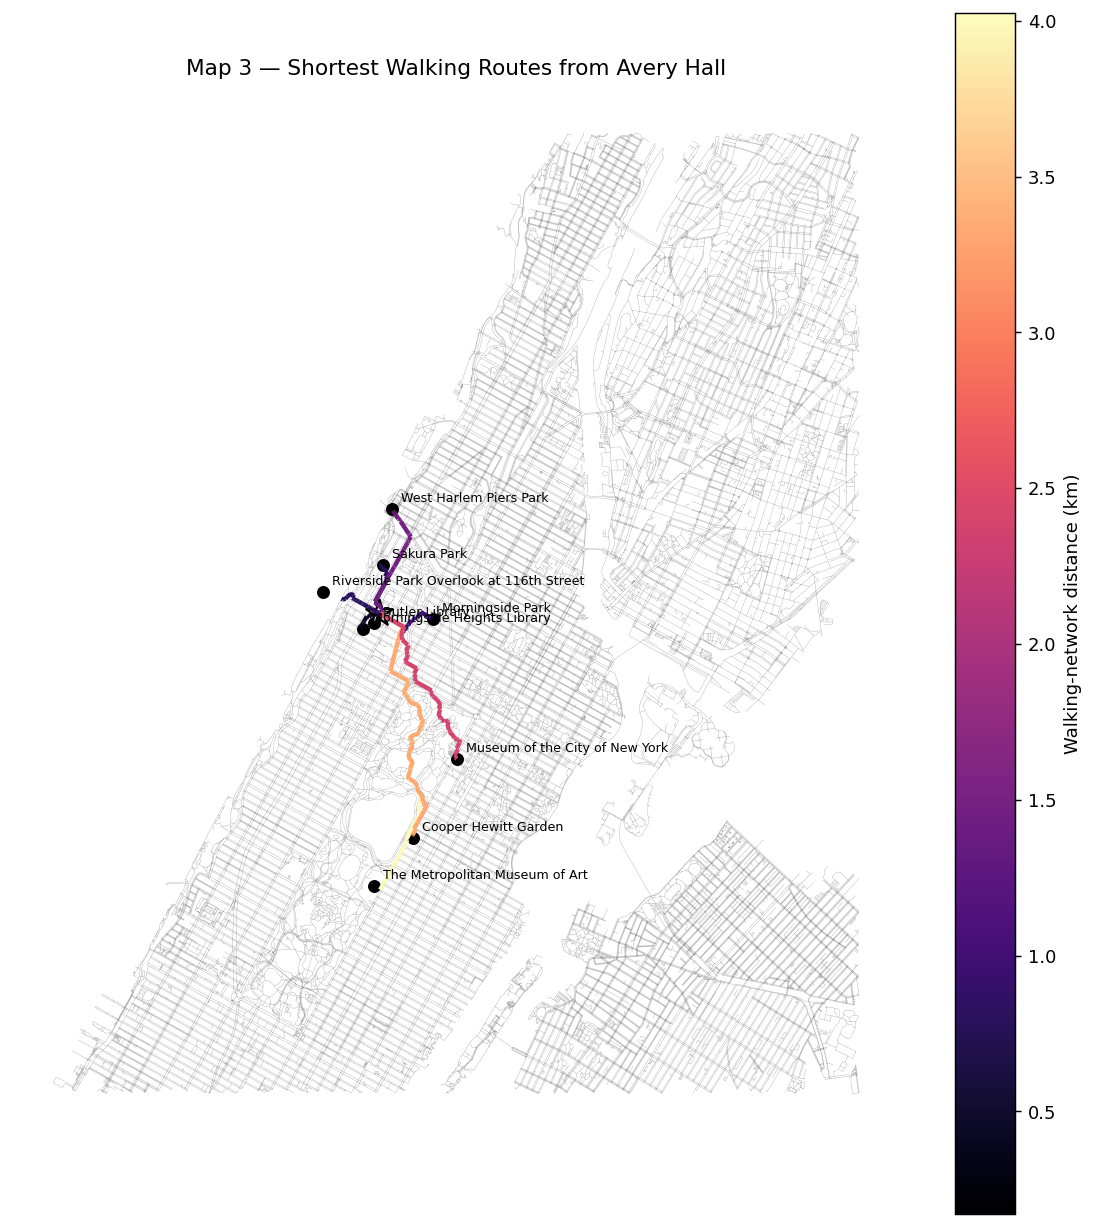

In [37]:

route_gdf = gpd.GeoDataFrame(
    destinations.drop(columns="geometry"),
    geometry=destinations["route_geom"],
    crs=net_edges.crs,
)

fig, ax = plt.subplots(figsize=(11, 12))

net_edges.plot(
    ax=ax,
    color="black",
    linewidth=0.2,
    alpha=0.18,
)

route_gdf.plot(
    ax=ax,
    column="network_km",
    cmap="magma",
    linewidth=2.4,
    legend=True,
    legend_kwds={
        "label": "Walking-network distance (km)"
    },
)

destinations.plot(
    ax=ax,
    color="black",
    markersize=38,
)

origin.plot(
    ax=ax,
    marker="*",
    color="white",
    edgecolor="black",
    markersize=240,
    linewidth=1.2,
)

for _, row in destinations.iterrows():
    ax.annotate(
        row["place_name"],
        (row.geometry.x, row.geometry.y),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_title(
    "Map 3 — Shortest Walking Routes from Avery Hall"
)
ax.set_axis_off()
plt.show()


## 10. Charts comparing Euclidean and network distance

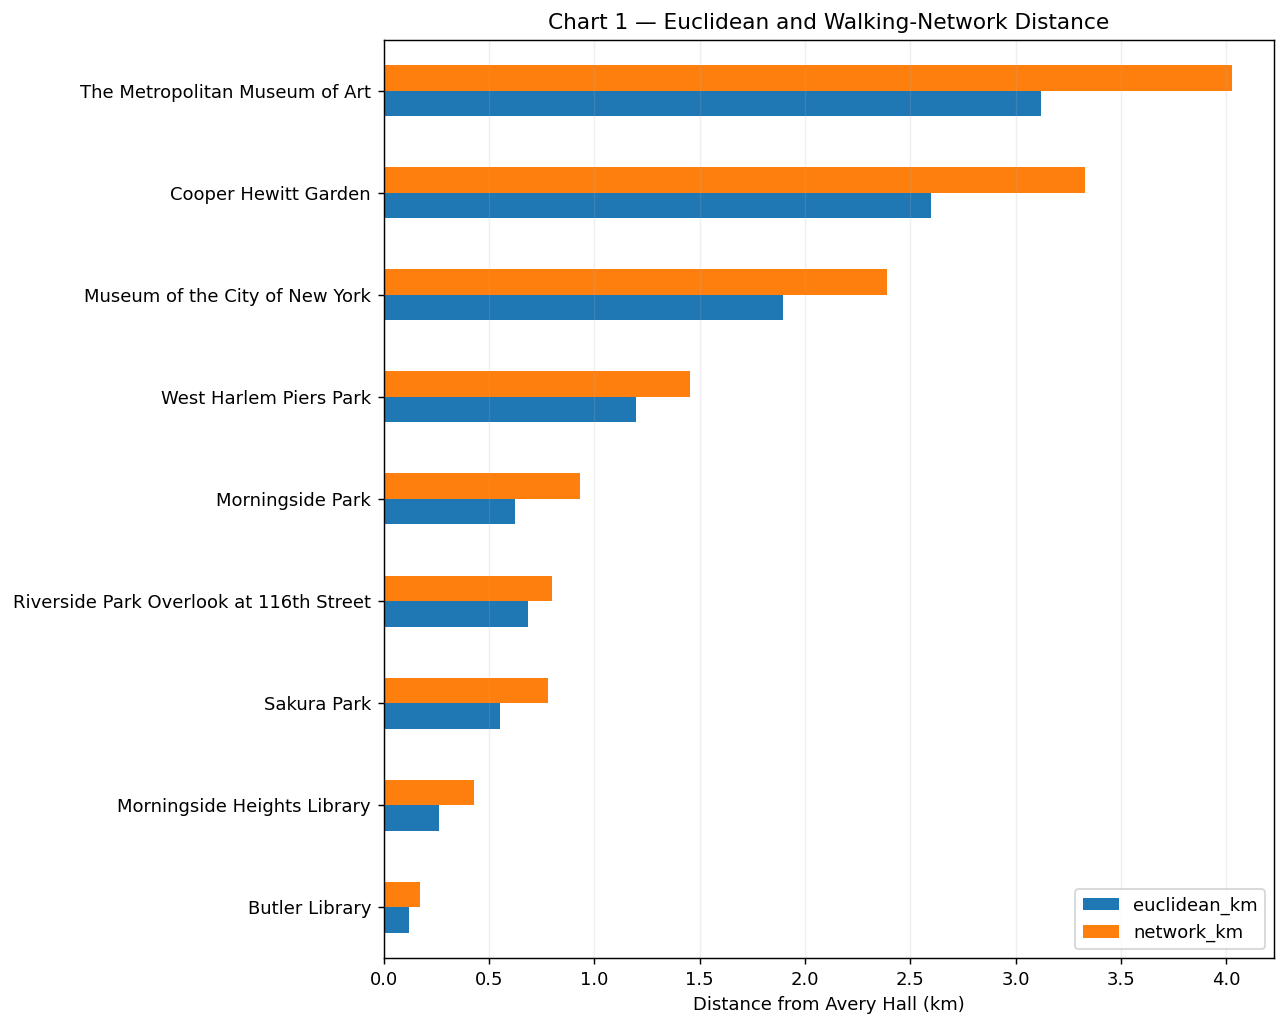

In [38]:

comparison = destinations[
    [
        "place_name",
        "euclidean_km",
        "network_km",
    ]
].copy()

comparison = comparison.sort_values(
    "network_km"
).set_index("place_name")

ax = comparison.plot(
    kind="barh",
    figsize=(10, 8),
)

ax.set_xlabel("Distance from Avery Hall (km)")
ax.set_ylabel("")
ax.set_title(
    "Chart 1 — Euclidean and Walking-Network Distance"
)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


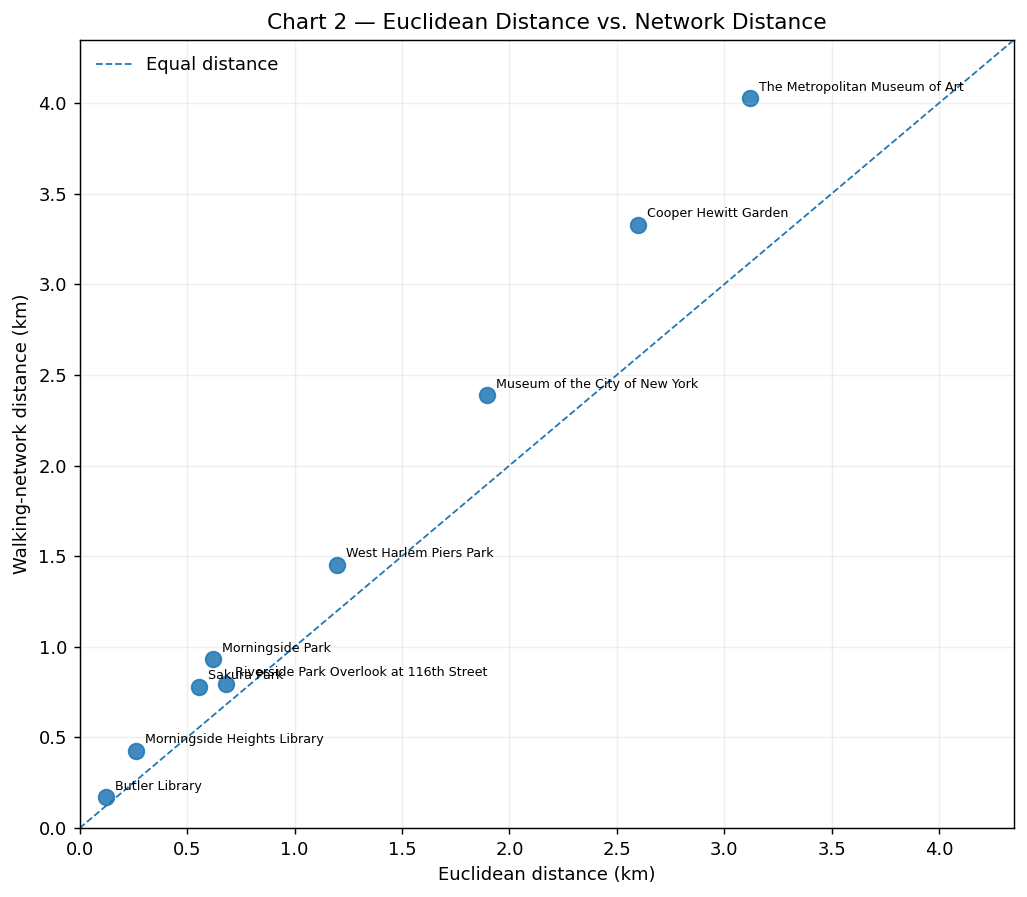

In [39]:

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    destinations["euclidean_km"],
    destinations["network_km"],
    s=75,
    alpha=0.85,
)

maximum = max(
    destinations["euclidean_km"].max(),
    destinations["network_km"].max(),
) * 1.08

ax.plot(
    [0, maximum],
    [0, maximum],
    linestyle="--",
    linewidth=1,
    label="Equal distance",
)

for _, row in destinations.iterrows():
    ax.annotate(
        row["place_name"],
        (
            row["euclidean_km"],
            row["network_km"],
        ),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_xlim(0, maximum)
ax.set_ylim(0, maximum)
ax.set_xlabel("Euclidean distance (km)")
ax.set_ylabel("Walking-network distance (km)")
ax.set_title(
    "Chart 2 — Euclidean Distance vs. Network Distance"
)
ax.legend(frameon=False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


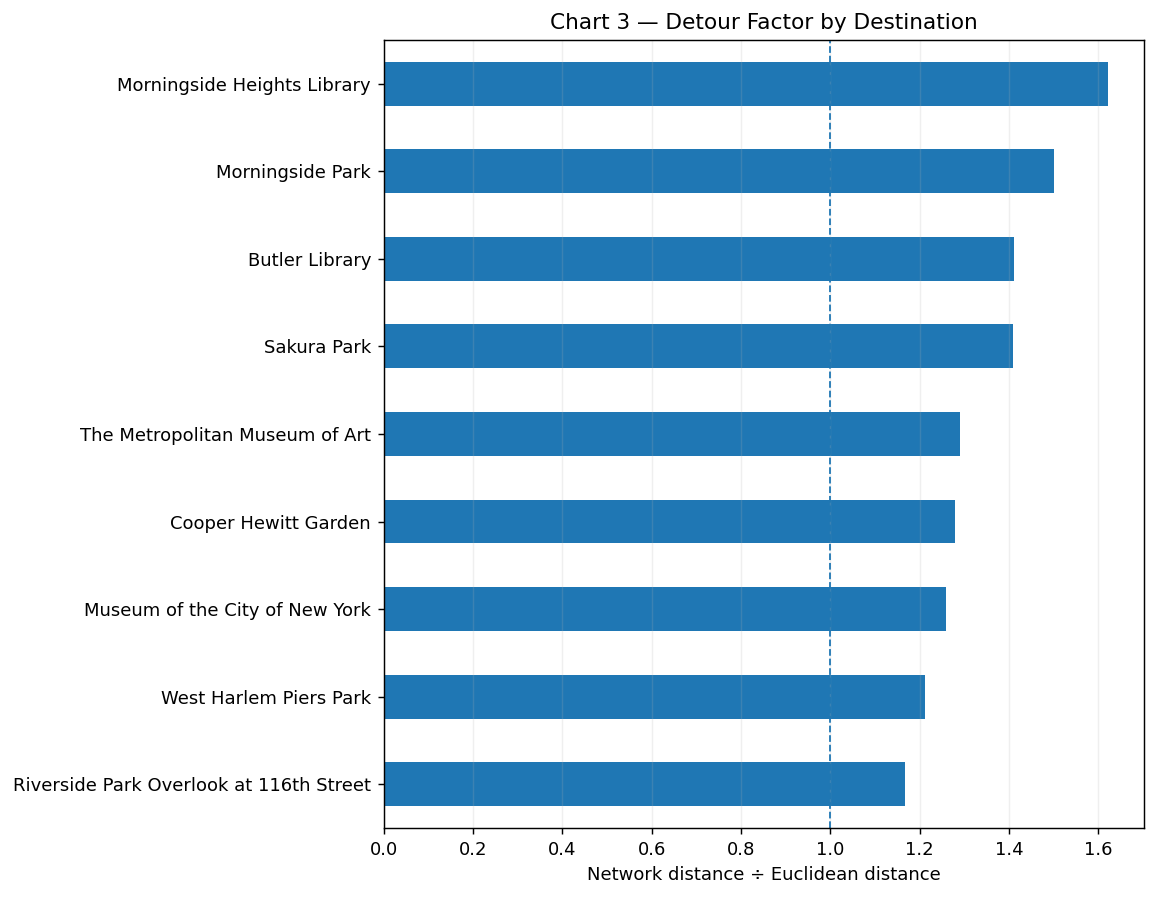

In [40]:

detour_plot = (
    destinations[
        [
            "place_name",
            "detour_factor",
        ]
    ]
    .sort_values("detour_factor")
    .set_index("place_name")
)

ax = detour_plot.plot(
    kind="barh",
    legend=False,
    figsize=(9, 7),
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Network distance ÷ Euclidean distance"
)
ax.set_ylabel("")
ax.set_title(
    "Chart 3 — Detour Factor by Destination"
)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


## 11. Inspect the strongest differences

In [41]:

destinations[
    result_columns
].sort_values(
    "detour_factor",
    ascending=False,
).round(2)


,place_name,euclidean_km,network_km,extra_distance_km,detour_factor,euclidean_rank,network_rank,rank_change
2,Morningside Heights Library,0.26,0.43,0.16,1.62,2,2,0
6,Morningside Park,0.62,0.93,0.31,1.50,4,5,1
1,Butler Library,0.12,0.17,0.05,1.41,1,1,0
3,Sakura Park,0.55,0.78,0.23,1.41,3,3,0
12,The Metropolitan Museum of Art,3.12,4.03,0.91,1.29,9,9,0
14,Cooper Hewitt Garden,2.60,3.33,0.73,1.28,8,8,0
15,Museum of the City of New York,1.90,2.39,0.49,1.26,7,7,0
5,West Harlem Piers Park,1.20,1.45,0.25,1.21,6,6,0
4,Riverside Park Overlook at 116th Street,0.68,0.80,0.11,1.17,5,4,-1



## Reflection

The results show that geometric proximity and experienced accessibility are
not equivalent. Every destination requires a longer route through the
pedestrian network than its direct Euclidean distance suggests, but the size of
this difference varies considerably.

Morningside Park produces one of the highest detour factors. Its Euclidean
distance from Avery Hall is approximately 0.62 km, while its walking-network
distance is approximately 0.91 km, producing a detour factor of 1.46. Although
the park appears relatively close on the map, the street layout and available
entrances require a more indirect walking route.

Morningside Heights Library shows a similar pattern at a smaller scale. Its
Euclidean distance is approximately 0.26 km, but its network distance increases
to approximately 0.38 km. This demonstrates that even a nearby destination can
feel less immediate when the entrance and street network do not align with the
direct line between two places.

The Metropolitan Museum of Art has one of the largest absolute differences.
Its Euclidean distance is approximately 3.12 km, while the walking-network
distance is approximately 3.93 km, adding about 0.81 km to the journey. In this
case, Manhattan's street orientation and the need to move around the Central
Park edge make the experienced journey substantially longer than the apparent
distance.

By comparison, Butler Library has a detour factor of approximately 1.14. Its
network route is relatively close to its straight-line distance because the
destination is nearby and aligns more directly with the surrounding pedestrian
network.

These comparisons show that Euclidean distance is primarily visual and
abstract: it describes how close two points appear in Cartesian space. Network
distance is navigational and embodied: it describes the streets, turns,
crossings, and entrances that a pedestrian must actually negotiate.

For the refuge-space project, this distinction matters because a place is not
accessible simply because it is geographically close. Its usefulness as a
refuge also depends on how directly and easily it can be reached through the
city's circulation system.

### Experiential difference

- **Euclidean distance** is visual and abstract. It describes apparent
  proximity.
- **Network distance** is navigational and experiential. It describes the route
  that must actually be traveled.

### Limitations

The OSMnx network is more realistic than a custom grid, but it remains a model.
It does not fully represent traffic-signal waiting time, crowds, slope, weather,
construction, safety, accessibility conditions, or whether a refuge is open.
Points are also snapped to the nearest network node, which can introduce small
errors when an entrance is not represented precisely.


## 12. Export calculated results

In [42]:

export_columns = [
    "place_name",
    "place_type",
    "neighborhood",
    "euclidean_m",
    "network_m",
    "extra_distance_m",
    "detour_factor",
    "euclidean_rank",
    "network_rank",
    "rank_change",
    "geometry",
]

destinations[
    export_columns
].to_file(
    "network_distance_results.geojson",
    driver="GeoJSON",
)

destinations[
    [
        column
        for column in export_columns
        if column != "geometry"
    ]
].to_csv(
    "network_distance_results.csv",
    index=False,
)

route_gdf[
    [
        "place_name",
        "network_m",
        "network_km",
        "geometry",
    ]
].to_file(
    "shortest_routes.geojson",
    driver="GeoJSON",
)

print("Saved:")
print("- network_distance_results.geojson")
print("- network_distance_results.csv")
print("- shortest_routes.geojson")


Saved:
- network_distance_results.geojson
- network_distance_results.csv
- shortest_routes.geojson
